<a href="https://colab.research.google.com/github/Aatka-Saleem/ML-Core-Implementations/blob/main/06-Deep-Learning-%26--Neural-Networks/Using_Pretrained_Models_in_all_three_ways.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import numpy as np
from sklearn.datasets import load_files
from keras import utils
from tensorflow.keras.utils import img_to_array, load_img, array_to_img
from sklearn.model_selection import train_test_split

from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input as preprocess_input_vgg
from keras.applications.vgg16 import decode_predictions as decode_vgg
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.models import Model
from keras.optimizers import Adam

**This note book will demontrate how a pretrained model can be used as a classifier, feature extractor and with fine tuning.**

**To keep things simple, all three examples have been demonstrated using just one pre-trained model which is VGG16.**

**Also, we will use a new dataset of images of cats and dogs, details of which are discussed in the following cells.**

**It is recommended to use Google Colab or some GPU based platform for faster execution.**

# The Pre-trained model: VGG16
- Created by researchers at oxford university UK.
- VGG16 is a 16 layer convolutional neural network trained on more than a million images from the ImageNet database.
- Can classify images into over 1000 object categories, such as keyboard, mouse, pencil, and many animals.
- The VGG network requires an image input of size 224-by-224, in the form of 4D tensor of shape (samples, height, width, channels).


- For other models, see [keras pre-trained applications](https://keras.io/api/applications/)

# Mounting Google Drive
- This code will mount my google drive on Colab.
- We upload the data on our drive then we mount it in Colab to avoid loading process again and again.
- It is helpful if Google Colab is used, not required if the code is run on Anaconda.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


**Setting path to folder in gdrive containing the notebook and the dataset**

In [ ]:
PATH = '/content/gdrive/MyDrive/catsndogs'

# The Dataset

- The dataset contains images of cats and dogs.
- Source: https://www.microsoft.com/en-us/download/confirmation.aspx?id=54765

- The original dataset contains a total of 25000 images with 12500 images of cats and dogs each. Size of data set is 786.7 MB.

- Here we are using only 600 images, 300 from each class (attached with the notebook).
- These 600 images have been placed in a folder called 'catsndogs', which further contains two folders, one called 'Class_a' containing images of cats, and the second one called 'Class_b' containing images of dogs.

### Creating 4D tensor of all images and setting labels for test data

Here we intend to create a single binary outout, where label 0 is cat and label 1 is dog. Hence we will ise Sigmoid activation function in the output layer. The following code supports this version.

Alternatively, two separate labels can also be defined for the two classes. Then we will have to set out output layer as Softmax.

In [ ]:
#This method takes path of the folder where images are placed and then creates and returns two arrays:
#The first one contains the list of all filenames, and
#The second one contains the list of all corresponding labels
path = f'{PATH}/catsndogs'
def load_dataset(path):
    data = load_files(path)
    # This method reads files arranged in subfolders, where each subfolder represents a class label.
    # The variable data becomes a Bunch object (similar to a dictionary) containing:
    # - data.data (list of file contents)
    # - data.target (numeric labels)
    # - data.target_names (class names / folder names)
    # - data.filenames (paths of files)

    paths = np.array(data['filenames'])
    targets = utils.to_categorical(np.array(data['target']))
    single_target=[]
    for i in targets: #Label 0 is cat and 1 is dog
        if i[0]==0.:
            single_target.append(1) #for cat
        else:
            single_target.append(0) #for dog
    target=np.array(single_target)
    return paths, target
files, target = load_dataset(f'{PATH}/catsndogs') #in colab put path of folder here

#This method loads an image, converts it to binary, and then adds a dimension to it.
def path_to_tensor(img_path):
    img = load_img(img_path, target_size=(224, 224)) #Loading an RGB image as PIL.Image.Image type
    x = img_to_array(img) #Converting the PIL.Image.Image type to a 3D tensor with shape (224, 224, 3)
    return np.expand_dims(x, axis=0) #Converting the 3D tensor to a 4D tensor with shape (1, 224, 224, 3) and returns the 4D tensor

#This method returns a 4D tensor of all images in binary form
def paths_to_tensor(img_paths):
    list_of_tensors = [path_to_tensor(img_path) for img_path in img_paths]
    return np.vstack(list_of_tensors)

image_tensors = paths_to_tensor(files)

Let's explore what the variables files, target and image_tensors contain

In [ ]:
files
#Contains array of all file names

array(['/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/219.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_a/208.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_a/30.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/26.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_a/283.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/71.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/217.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/32.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/223.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_a/244.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/111.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_b/189.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_a/254.jpg',
       '/content/gdrive/MyDrive/catsndogs/catsndogs/Class_a/84.jpg',
       '/content/gdrive/M

In [ ]:
target
#Contains array of binary labels

array([1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1,

In [ ]:
target.shape

(600,)

In [ ]:
image_tensors
#4D array of images

array([[[[ 61.,  49.,  53.],
         [ 62.,  54.,  52.],
         [ 55.,  50.,  44.],
         ...,
         [160., 167., 177.],
         [155., 161., 175.],
         [148., 154., 170.]],

        [[ 61.,  48.,  55.],
         [ 54.,  45.,  46.],
         [ 54.,  49.,  45.],
         ...,
         [165., 172., 182.],
         [159., 165., 179.],
         [151., 157., 173.]],

        [[ 51.,  42.,  47.],
         [ 42.,  33.,  34.],
         [ 48.,  43.,  40.],
         ...,
         [172., 179., 189.],
         [164., 172., 185.],
         [155., 162., 178.]],

        ...,

        [[ 49.,  44.,  22.],
         [ 46.,  52.,  26.],
         [ 42.,  53.,  23.],
         ...,
         [222., 242., 241.],
         [222., 242., 241.],
         [222., 242., 241.]],

        [[ 49.,  44.,  22.],
         [ 46.,  52.,  26.],
         [ 41.,  51.,  24.],
         ...,
         [222., 242., 241.],
         [222., 242., 241.],
         [222., 242., 241.]],

        [[ 50.,  46.,  21.],
       

In [ ]:
image_tensors.shape

(600, 224, 224, 3)

### Checking out some random images for verification

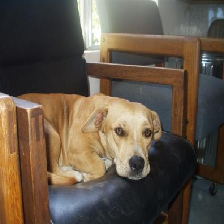

A dog


In [ ]:
img_no=30
display(array_to_img(image_tensors[img_no]))

if target[img_no]==0:
    print('A cat')
else:
    print('A dog')

### Preprocessing the images as per requirement of the VGG model

In [ ]:
images = preprocess_input_vgg(image_tensors)

- Now 'images' contains the preprocessed 4D tensor of images and 'target' contains the corrresponding labels.

### Spliting into train, valid and test sets

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(images, target,test_size=0.1,random_state=0)
X_train,X_valid,Y_train,Y_valid = train_test_split(X_train, Y_train,test_size=0.2,random_state=0)
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_valid:', X_valid.shape)
print('Shape of Y_valid:', Y_valid.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape)

Shape of X_train: (432, 224, 224, 3)
Shape of Y_train: (432,)
Shape of X_valid: (108, 224, 224, 3)
Shape of Y_valid: (108,)
Shape of X_test: (60, 224, 224, 3)
Shape of Y_test: (60,)


# Case 1: Using a pre-trained network as classifier

### Downloading the model and its pre-trained weights

In [ ]:
%%time
vgg_case1 = VGG16(weights = "imagenet", input_shape = (224,224, 3))

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
CPU times: user 4.09 s, sys: 2.37 s, total: 6.46 s
Wall time: 19.4 s


In [ ]:
vgg_case1.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

**Note all 138,357.544 parameters are trainable (not frozen) right now.**

### Making Prediction on an image

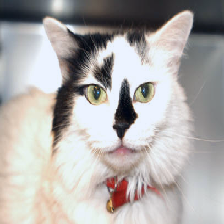

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n02124075', 'Egyptian_cat', np.float32(0.20713118)),
  ('n02123045', 'tabby', np.float32(0.1590458)),
  ('n04553703', 'washbasin', np.float32(0.06207976)),
  ('n02883205', 'bow_tie', np.float32(0.052899025)),
  ('n02127052', 'lynx', np.float32(0.04768717))]]

In [ ]:
img_no=1

display(array_to_img(image_tensors[img_no]))

selected_img=np.expand_dims(images[img_no], axis=0)
#Predicting the probability across all output classes
prediction_vgg_case1 = vgg_case1.predict(selected_img)
prediction_vgg_case1

#Converting the probabilities to class labels
labels=decode_vgg(prediction_vgg_case1)
labels

#Retrieving the most likely result with the highest probability
#labels[0][0]

### Evaluating the model
- We cannot evaluate the model here as VGG classifer supports 1000 classes, while our Y_test has only 2.

# Case 2: Using a pre-trained network as feature extractor

### Downloading the model without the classifier

In [ ]:
%%time
vgg_case2 = VGG16(weights = "imagenet", include_top=False, input_shape = (224,224, 3))
#include_top is false to ignore the fully connected classifier part on top of the model.

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CPU times: user 424 ms, sys: 130 ms, total: 554 ms
Wall time: 2.36 s


In [ ]:
vgg_case2.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Note that this tables doesnot have last four rows which were there in case I architecture.**

**These last four layers form the classifier of VGG16 (CNN) model, which we have excluded now.**

**All 14,714,688 parameters are trainable**

### Freezing the feature extraction layers

In [ ]:
for layer in vgg_case2.layers:
    layer.trainable = False

In [ ]:
vgg_case2.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

**Note that after freezing the layers all 14,714,688 weights have become non-trainable**

### Adding our custom classfiier

In [ ]:
last_layer_case2 = vgg_case2.get_layer('block5_pool') #Saving the last layer of the network

last_output_case2 = last_layer_case2.output #Saving the output of the last layer to be the input of the next layer

x1 = Flatten()(last_output_case2) #Flattenning the classifier input, which is the output of the last layer of the VGG16 model
x1 = Dense(64, activation='relu', name='FC_2')(x1) #Adding 1 dense layer of 64 neurons
x1 = Dropout(0.5)(x1)
x1 = Dense(1, activation='sigmoid', name='sigmoid')(x1) #Adding our new Sigmid layer for binary classification

model_vgg_case2 = Model(inputs=vgg_case2.input, outputs=x1) #Instantiating a new_model

model_vgg_case2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_2 (Dense)                    │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,320,449 (62.26 MB)

 Trainable params: 1,605,761 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Note the addition of 1,605,761 trainable parameters from our new layers**

### Compiling the model

In [ ]:
model_vgg_case2.compile(Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

### Training the model

In [ ]:
%%time
model_vgg_case2.fit(X_train, Y_train, batch_size=10, epochs=20, verbose=0, validation_data=(X_valid, Y_valid))

CPU times: user 27.1 s, sys: 3.54 s, total: 30.6 s
Wall time: 1min 26s


### Making Prediction on the image

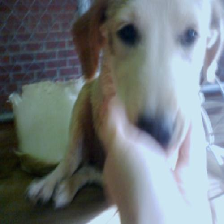

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
100.0 % probability that the image contains a dog


In [ ]:
img_no=0
display(array_to_img(image_tensors[img_no]))

selected_img=np.expand_dims(images[img_no], axis=0)

prediction_vgg_case2 = model_vgg_case2.predict(selected_img)
print(round(prediction_vgg_case2[0][0]*100,2),'% probability that the image contains a dog')

### Evaluating the model

In [ ]:
print('\nTesting loss: {:.4f}\nTesting accuracy: {:.4f}'.format(*model_vgg_case2.evaluate(X_test, Y_test)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 14s/step - accuracy: 0.9500 - loss: 0.7540

Testing loss: 0.7540
Testing accuracy: 0.9500


# Case 3: Using a pre-trained with fine tuning

### Downloading the model without the classifier

In [ ]:
%%time
vgg_case3 = VGG16(weights = "imagenet", include_top=False, input_shape = (224,224, 3))
#include_top is false to ignore the fully connected classifier part on top of the model.

CPU times: user 288 ms, sys: 0 ns, total: 288 ms
Wall time: 291 ms


In [ ]:
vgg_case3.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Note the number of trainable parameters**

### Freezing the feature extraction layers, leaving last 5 layers

In [ ]:
for layer in vgg_case3.layers[:-5]:
    layer.trainable = False

#Leaving last five layers of the extracter, freezing all the earlier layers.
#This counts pool layers too, so practically only last 3 weight layers are left unfrozen.

In [ ]:
vgg_case3.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

**Note and verify the number of trainable and non-trainable parameters**

### Adding our custom classfiier

In [ ]:
last_layer_case3 = vgg_case3.get_layer('block5_pool') #Saving the last layer of the network

last_output_case3 = last_layer_case3.output #Saving the output of the last layer to be the input of the next layer

x2 = Flatten()(last_output_case3) #Flattenning the classifier input, which is the output of the last layer of the VGG16 model
x2 = Dense(64, activation='relu', name='FC_2')(x2) #Adding 1 dense layer of 64 neurons
x2 = Dropout(0.5)(x2)
x2 = Dense(1, activation='sigmoid', name='sigmoid')(x2) #Adding our new Sigmid layer for binary classification

model_vgg_case3 = Model(inputs=vgg_case3.input, outputs=x2) #Instantiating a new_model

model_vgg_case3.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_2 (Dense)                    │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,320,449 (62.26 MB)

 Trainable params: 8,685,185 (33.13 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

**Again note and verify the number of trainable and non-trainable parameters**

### Compiling the model

In [ ]:
model_vgg_case3.compile(Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

### Training the model

In [ ]:
%%time
model_vgg_case3.fit(X_train, Y_train, batch_size=10, epochs=20, verbose=0, validation_data=(X_valid, Y_valid))

CPU times: user 24.2 s, sys: 3.92 s, total: 28.2 s
Wall time: 1min 42s


### Making Prediction on the image

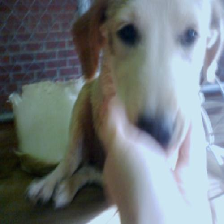

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
100.0 % probability that the image contains a dog


In [ ]:
img_no=0
display(array_to_img(image_tensors[img_no]))

selected_img=np.expand_dims(images[img_no], axis=0)

prediction_vgg_case2 = model_vgg_case2.predict(selected_img)
print(round(prediction_vgg_case2[0][0]*100,2),'% probability that the image contains a dog')

### Evaluating the model

In [ ]:
print('\nTesting loss: {:.4f}\nTesting accuracy: {:.4f}'.format(*model_vgg_case3.evaluate(X_test, Y_test)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step - accuracy: 0.9667 - loss: 0.2124

Testing loss: 0.2124
Testing accuracy: 0.9667


# Task for you

Modify the labels for two outputs and repeat case 2 and 3 with Softmax at output layer.

## Task for you: Repeat Case 2 and 3 with Softmax at output layer (new section)

As requested, here are Case 2 and Case 3 repeated with modifications to support two outputs using Softmax activation in the output layer and `categorical_crossentropy` loss. This requires modifying the `load_dataset` function to produce one-hot encoded labels instead of single binary labels.

First, we'll redefine the `load_dataset` function to return one-hot encoded targets.

In [ ]:
# Redefined load_dataset to return one-hot encoded labels for Softmax
path = f'/content/gdrive/MyDrive/catsndogs/catsndogs'
def load_dataset_softmax(path):
    data = load_files(path)
    paths = np.array(data['filenames'])
    # Convert integer labels (0 for Class_a, 1 for Class_b) to one-hot encoded categorical labels
    # For 2 classes, this will result in arrays like [1., 0.] for class 0 and [0., 1.] for class 1
    targets = utils.to_categorical(np.array(data['target']), num_classes=2)
    return paths, targets

# Load data using the new function
files_softmax, target_softmax = load_dataset_softmax(f'/content/gdrive/MyDrive/catsndogs/catsndogs')

# Re-create image tensors (assuming `image_tensors` from previous cells is still available and correct)
# If not, uncomment and run: image_tensors_softmax = paths_to_tensor(files_softmax)
# For simplicity, we will use the already loaded `image_tensors` which are raw images

# Preprocess images for VGG (same as before)
images_softmax = preprocess_input_vgg(image_tensors)

print('Shape of new target_softmax:', target_softmax.shape)

Shape of new target_softmax: (600, 2)


### Splitting into train, valid and test sets with new one-hot encoded labels

In [ ]:
X_train_softmax, X_test_softmax, Y_train_softmax, Y_test_softmax = train_test_split(images_softmax, target_softmax, test_size=0.1, random_state=0)
X_train_softmax, X_valid_softmax, Y_train_softmax, Y_valid_softmax = train_test_split(X_train_softmax, Y_train_softmax, test_size=0.2, random_state=0)

print('Shape of X_train_softmax:', X_train_softmax.shape)
print('Shape of Y_train_softmax (one-hot):', Y_train_softmax.shape)
print('Shape of X_valid_softmax:', X_valid_softmax.shape)
print('Shape of Y_valid_softmax (one-hot):', Y_valid_softmax.shape)
print('Shape of X_test_softmax:', X_test_softmax.shape)
print('Shape of Y_test_softmax (one-hot):', Y_test_softmax.shape)

Shape of X_train_softmax: (432, 224, 224, 3)
Shape of Y_train_softmax (one-hot): (432, 2)
Shape of X_valid_softmax: (108, 224, 224, 3)
Shape of Y_valid_softmax (one-hot): (108, 2)
Shape of X_test_softmax: (60, 224, 224, 3)
Shape of Y_test_softmax (one-hot): (60, 2)


---

## Case 2 (Softmax): Using a pre-trained network as feature extractor with Softmax

In [ ]:
%%time
vgg_case2_softmax = VGG16(weights="imagenet", include_top=False, input_shape=(224,224, 3))

for layer in vgg_case2_softmax.layers:
    layer.trainable = False

vgg_case2_softmax.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

CPU times: user 244 ms, sys: 22.2 ms, total: 266 ms
Wall time: 266 ms


### Adding custom classifier with Softmax output

In [ ]:
last_layer_case2_softmax = vgg_case2_softmax.get_layer('block5_pool')
last_output_case2_softmax = last_layer_case2_softmax.output

x1_softmax = Flatten()(last_output_case2_softmax)
x1_softmax = Dense(64, activation='relu', name='FC_2_softmax')(x1_softmax)
x1_softmax = Dropout(0.5)(x1_softmax)
x1_softmax = Dense(2, activation='softmax', name='softmax_output')(x1_softmax) # 2 neurons for 2 classes, Softmax activation

model_vgg_case2_softmax = Model(inputs=vgg_case2_softmax.input, outputs=x1_softmax)

model_vgg_case2_softmax.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC_2_softmax (Dense)            │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,320,514 (62.26 MB)

 Trainable params: 1,605,826 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Compiling the model with `categorical_crossentropy`

In [ ]:
model_vgg_case2_softmax.compile(Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

### Training the model

In [ ]:
%%time
model_vgg_case2_softmax.fit(X_train_softmax, Y_train_softmax, batch_size=10, epochs=20, verbose=0, validation_data=(X_valid_softmax, Y_valid_softmax))

CPU times: user 19.5 s, sys: 3.92 s, total: 23.4 s
Wall time: 1min 21s


### Making Prediction on an image (Case 2 Softmax)

In [ ]:
img_no=0 # Example image number
display(array_to_img(image_tensors[img_no])) # Display original image

selected_img_softmax=np.expand_dims(images_softmax[img_no], axis=0)

prediction_vgg_case2_softmax = model_vgg_case2_softmax.predict(selected_img_softmax)

class_names = ['Cat', 'Dog'] # Assuming class 0 is 'Cat', class 1 is 'Dog'
predicted_class_idx = np.argmax(prediction_vgg_case2_softmax[0])
predicted_probability = prediction_vgg_case2_softmax[0][predicted_class_idx]

print(f"The image is a {class_names[predicted_class_idx]} with {predicted_probability*100:.2f}% probability.")
print(f"Probabilities: Cat={prediction_vgg_case2_softmax[0][0]*100:.2f}%, Dog={prediction_vgg_case2_softmax[0][1]*100:.2f}%")

### Evaluating the model (Case 2 Softmax)

In [ ]:
print('\nTesting loss: {:.4f}\nTesting accuracy: {:.4f}'.format(*model_vgg_case2_softmax.evaluate(X_test_softmax, Y_test_softmax)))

---

## Case 3 (Softmax): Using a pre-trained network with fine tuning and Softmax

In [ ]:
%%time
vgg_case3_softmax = VGG16(weights="imagenet", include_top=False, input_shape=(224,224, 3))

# Freezing the feature extraction layers, leaving last 5 layers
for layer in vgg_case3_softmax.layers[:-5]:
    layer.trainable = False

vgg_case3_softmax.summary()

### Adding custom classifier with Softmax output

In [ ]:
last_layer_case3_softmax = vgg_case3_softmax.get_layer('block5_pool')
last_output_case3_softmax = last_layer_case3_softmax.output

x2_softmax = Flatten()(last_output_case3_softmax)
x2_softmax = Dense(64, activation='relu', name='FC_2_softmax_tuned')(x2_softmax)
x2_softmax = Dropout(0.5)(x2_softmax)
x2_softmax = Dense(2, activation='softmax', name='softmax_output_tuned')(x2_softmax) # 2 neurons for 2 classes, Softmax activation

model_vgg_case3_softmax = Model(inputs=vgg_case3_softmax.input, outputs=x2_softmax)

model_vgg_case3_softmax.summary()

### Compiling the model with `categorical_crossentropy`

In [ ]:
model_vgg_case3_softmax.compile(Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

### Training the model

In [ ]:
%%time
model_vgg_case3_softmax.fit(X_train_softmax, Y_train_softmax, batch_size=10, epochs=20, verbose=0, validation_data=(X_valid_softmax, Y_valid_softmax))

### Making Prediction on an image (Case 3 Softmax)

In [ ]:
img_no=0 # Example image number
display(array_to_img(image_tensors[img_no])) # Display original image

selected_img_softmax=np.expand_dims(images_softmax[img_no], axis=0)

prediction_vgg_case3_softmax = model_vgg_case3_softmax.predict(selected_img_softmax)

class_names = ['Cat', 'Dog'] # Assuming class 0 is 'Cat', class 1 is 'Dog'
predicted_class_idx = np.argmax(prediction_vgg_case3_softmax[0])
predicted_probability = prediction_vgg_case3_softmax[0][predicted_class_idx]

print(f"The image is a {class_names[predicted_class_idx]} with {predicted_probability*100:.2f}% probability.")
print(f"Probabilities: Cat={prediction_vgg_case3_softmax[0][0]*100:.2f}%, Dog={prediction_vgg_case3_softmax[0][1]*100:.2f}%")

### Evaluating the model (Case 3 Softmax)

In [ ]:
print('\nTesting loss: {:.4f}\nTesting accuracy: {:.4f}'.format(*model_vgg_case3_softmax.evaluate(X_test_softmax, Y_test_softmax)))